# Credit Score Classification

In [25]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score
from sklearn.tree import DecisionTreeClassifier
import re

In [26]:
#Read Dataset
df= pd.read_csv('dataset/train.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

/var/folders/g_/wx182l8j3rjdrb5rv53tf7180000gn/T/ipykernel_36373/1022397046.py:2: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv('dataset/train.csv')


In [27]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


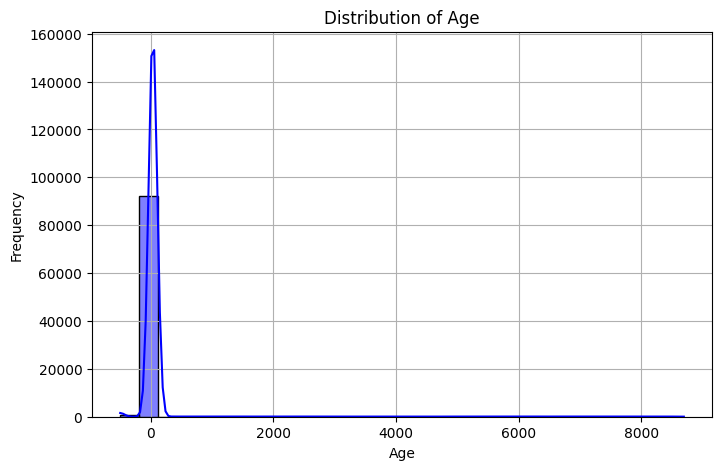

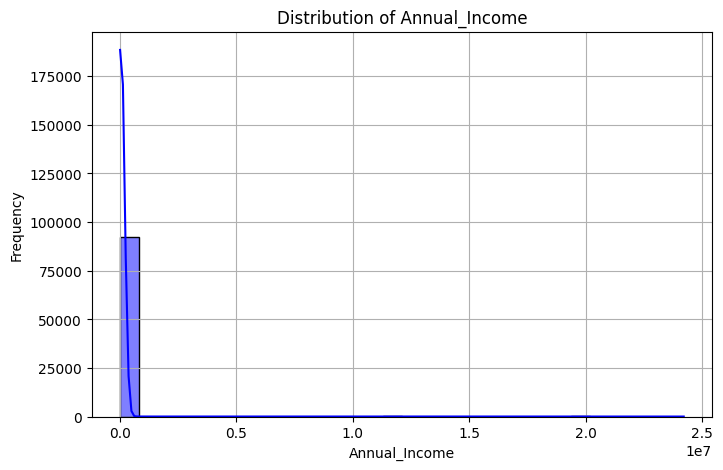

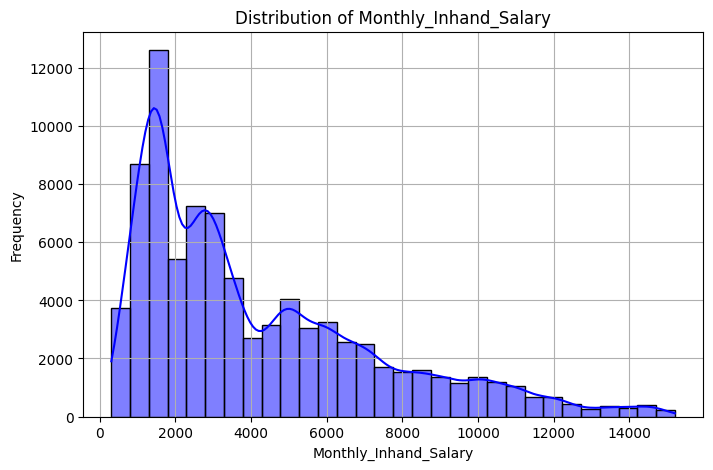

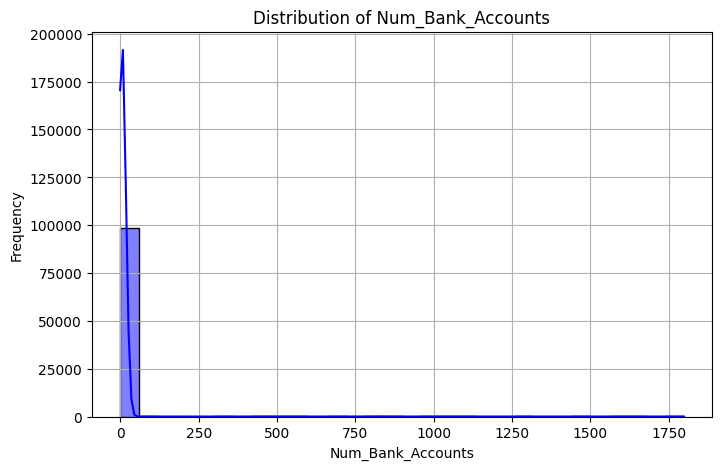

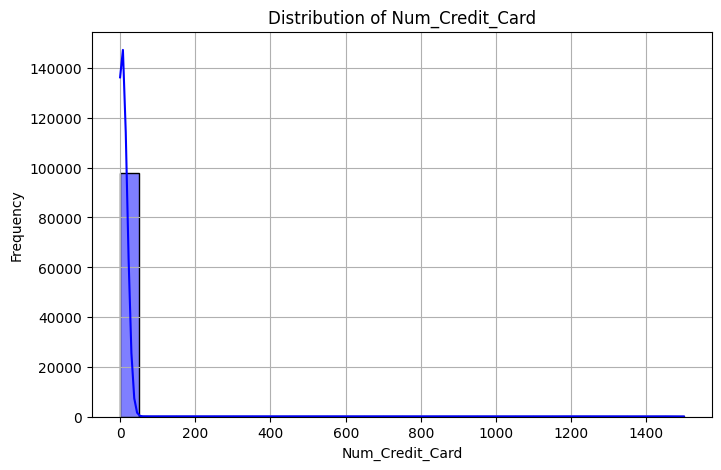

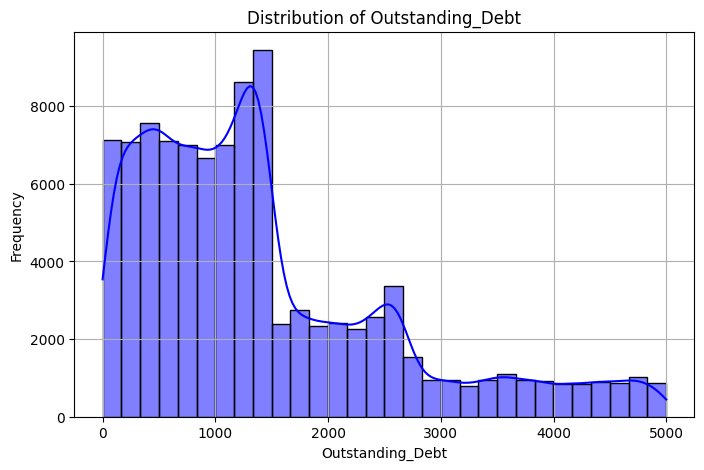

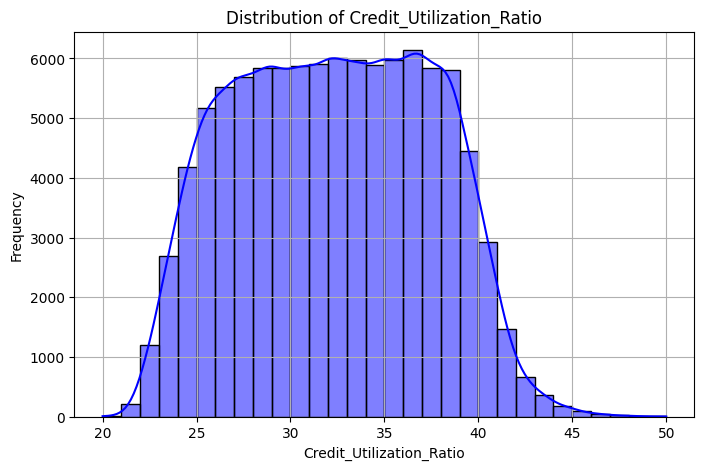

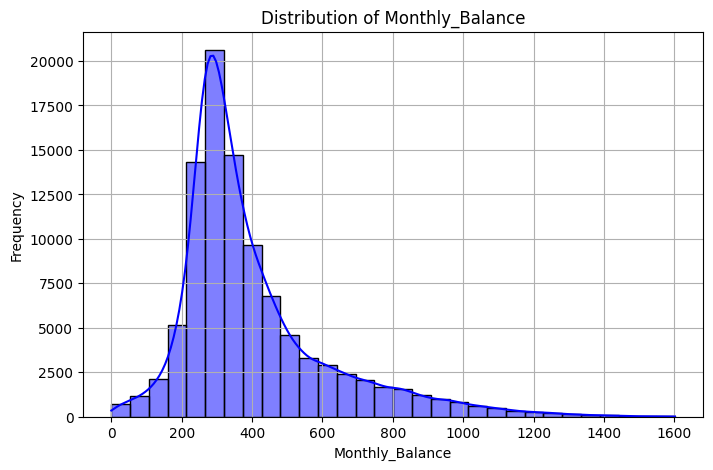

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert columns to numeric where applicable, handling errors gracefully
numeric_columns = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
                   'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Outstanding_Debt',
                   'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly',
                   'Monthly_Balance']
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Define key features for visualization
key_features = [
    'Age',
    'Annual_Income',
    'Monthly_Inhand_Salary',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Outstanding_Debt',
    'Credit_Utilization_Ratio',
    'Monthly_Balance',
]

# Set up visualizations
for feature in key_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[feature], kde=True, bins=30, color='blue', edgecolor='black')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()


In [29]:
#Drop duplicate rows
df.drop_duplicates(inplace=True)

#Drop unimportant columns
df = df.drop(['ID','Customer_ID','Month','Name','SSN', 'Type_of_Loan', 'Changed_Credit_Limit', 'Monthly_Inhand_Salary'], axis = 1)

#Correct the Age column by addressing anomalies: rows with invalid values such as ages less than 1, greater than 100, or containing non-numeric characters
df['Age'] = df['Age'].str.replace(r'\D', '', regex=True).astype(int)
df = df[df['Age']>0][df['Age']< 100]

#Replace the '_______' value in the Occupation field with Other
df['Occupation'] = df['Occupation'].replace('_______', 'Other')

#Convert the Annual_income column to float type
df['Annual_Income'] = df['Annual_Income'].str.replace('_', '').astype(float)

#Correct the Num_Bank_Accounts with negative value and huge value:
df = df[df['Num_Bank_Accounts']>=0]

#Convert Num_of_Loan to int type and correct it
df['Num_of_Loan'] = df['Num_of_Loan'].str.replace('_', '').astype(int)
df = df[df['Num_of_Loan']>0][df['Num_of_Loan']<100]

#Covert Num_of_Delayed_Payment to int type and correct it
df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].str.replace('_', '').dropna().astype(int)
df = df[df['Num_of_Delayed_Payment']>0]

#Covert Outstanding_Debt to int type and correct it
df['Outstanding_Debt'] = df['Outstanding_Debt'].str.replace('_', '').astype(float)

#Convert Credit_History_Age to a float number of days
def age2days(text,years=0,months=0):
    years_match = re.search(r'(\d+) Years?', text, re.IGNORECASE)
    months_match = re.search(r'(\d+) Months?', text, re.IGNORECASE)
    days_in_year = 365.25
    days_in_month = 30.44
    years = int(years_match.group(1)) if years_match else 0
    months = int(months_match.group(1)) if months_match else 0
    return (years * days_in_year) + (months * days_in_month)

df = df.dropna(subset=['Credit_History_Age'])
df['Credit_History_Age'] = df['Credit_History_Age'].apply(age2days)

#Correct Typo
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].str.replace('NM', 'No')

#Convert amout invested monthly to float
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].str.replace('_', '').astype(float)

#Drop Typo
df = df[df['Payment_Behaviour']!='!@9#%8']

#Convert mothly balance to float
df['Monthly_Balance'] = df['Monthly_Balance'].str.replace('_', '').astype(float)
df = df[df['Monthly_Balance']>0]


AttributeError: Can only use .str accessor with string values!

In [ ]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 57427 entries, 0 to 98303
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       57427 non-null  int64  
 1   Occupation                57427 non-null  object 
 2   Annual_Income             57427 non-null  float64
 3   Num_Bank_Accounts         57427 non-null  int64  
 4   Num_Credit_Card           57427 non-null  int64  
 5   Interest_Rate             57427 non-null  int64  
 6   Num_of_Loan               57427 non-null  int64  
 7   Delay_from_due_date       57427 non-null  int64  
 8   Num_of_Delayed_Payment    57427 non-null  float64
 9   Num_Credit_Inquiries      57427 non-null  float64
 10  Credit_Mix                57427 non-null  object 
 11  Outstanding_Debt          57427 non-null  float64
 12  Credit_Utilization_Ratio  57427 non-null  float64
 13  Credit_History_Age        57427 non-null  float64
 14  Payment_of_

In [ ]:
label_encoder = LabelEncoder()

columns_to_encode = ['Occupation', 'Credit_Mix','Payment_of_Min_Amount','Payment_Behaviour','Credit_Score']

for col in columns_to_encode:
    df[col] = label_encoder.fit_transform(df[col])

df.head(5)

,Age,Occupation,Annual_Income,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,23,13,19114.12,3,4,3,4,3,7.0,4.0,3,809.98,26.822620,8065.94,0,49.574949,80.415295,2,312.494089,0
3,23,13,19114.12,3,4,3,4,5,4.0,4.0,1,809.98,31.377862,8157.26,0,49.574949,199.458074,5,223.451310,0
6,23,13,19114.12,3,4,3,4,3,8.0,4.0,1,809.98,22.537593,8248.58,0,49.574949,178.344067,5,244.565317,0
8,28,12,34847.84,2,4,6,1,3,4.0,2.0,1,605.03,24.464031,9709.58,0,18.816215,104.291825,5,470.690627,2
9,28,14,34847.84,2,4,6,1,7,1.0,2.0,1,605.03,38.550848,9740.02,0,18.816215,40.391238,0,484.591214,0


In [ ]:
X = df.drop(columns=['Credit_Score'], axis=1).values
y = df['Credit_Score'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
print(mse,acc)

0.8071565383945672 0.591676823959603


In [ ]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}",mse)

Accuracy: 0.69 0.6312032039004005
